# Japan Birth analysis(1899-2023)

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 

In [2]:
df = pd.read_csv("../data/japan_birth_statistics_1899_2023.csv")
df = df.sort_values("year").reset_index(drop=True)  #oldest year first, newest last , rest_index fixes the index number


In [3]:
df.shape

(122, 7)

In [4]:
df.columns

Index(['year', 'total_births', 'male_births', 'female_births',
       'crude_birth_rate', 'sex_ratio_at_birth', 'total_fertility_rate'],
      dtype='object')

In [5]:
df.head(10) # Top 10 values

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
0,1899,1386981,713442,673539,32.0,105.9,NaN
1,1900,1420534,727916,692618,32.4,105.1,NaN
2,1901,1501591,769494,732097,33.9,105.1,NaN
3,1902,1510835,773296,737539,33.6,104.8,NaN
4,1903,1489816,763806,726010,32.7,105.2,NaN
5,1904,1440371,738230,702141,31.2,105.1,NaN
6,1905,1452770,735948,716822,31.2,102.7,NaN
7,1906,1394295,726155,668140,29.6,108.7,NaN
8,1907,1614472,818114,796358,34.0,102.7,NaN
9,1908,1662815,850209,812606,34.7,104.6,NaN


In [6]:
df.dtypes #Checking the column name and datatypes

year                      int64
total_births              int64
male_births               int64
female_births             int64
crude_birth_rate        float64
sex_ratio_at_birth      float64
total_fertility_rate    float64
dtype: object

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,122.0,1.961393e+03,36.585812,1899.0,1929.250,1962.50,1992.750,2023.00
total_births,122.0,1.619319e+06,439286.360806,727288.0,1212138.000,1656495.00,1985485.500,2696638.00
male_births,122.0,8.304865e+05,224926.109670,372603.0,623344.750,849471.00,1014098.250,1380008.00
female_births,122.0,7.888323e+05,214416.989182,354685.0,588793.250,805848.00,967350.000,1316630.00
crude_birth_rate,122.0,2.082459e+01,10.534323,6.0,9.825,18.60,32.375,36.20
sex_ratio_at_birth,122.0,1.053107e+02,0.858387,102.7,104.900,105.30,105.800,108.70
total_fertility_rate,77.0,1.860779e+00,0.696069,1.2,1.390,1.72,2.050,4.54


In [8]:
df.describe(include="int64")

,year,total_births,male_births,female_births
count,122.000000,1.220000e+02,1.220000e+02,1.220000e+02
mean,1961.393443,1.619319e+06,8.304865e+05,7.888323e+05
std,36.585812,4.392864e+05,2.249261e+05,2.144170e+05
min,1899.000000,7.272880e+05,3.726030e+05,3.546850e+05
25%,1929.250000,1.212138e+06,6.233448e+05,5.887932e+05
50%,1962.500000,1.656495e+06,8.494710e+05,8.058480e+05
75%,1992.750000,1.985486e+06,1.014098e+06,9.673500e+05
max,2023.000000,2.696638e+06,1.380008e+06,1.316630e+06


# Data Cleaning

In [9]:
# Checking the missing values from whole Table
missing_count = df.isnull().sum()
missing_count

year                     0
total_births             0
male_births              0
female_births            0
crude_birth_rate         0
sex_ratio_at_birth       0
total_fertility_rate    45
dtype: int64

Total fertility rate is 45 null values in past many years before the fertility rate evalution  

In [10]:
# Finding Total_fertility_rate min year and max year and total 

tfr_available = df.dropna(subset=["total_fertility_rate"])
print(f"TFR data starts :{tfr_available["year"].min()}")
print(f"TFR data ends :{tfr_available["year"].max()}")
print(f'Years with TFR  : {len(tfr_available)} out of {len(df)} total')


TFR data starts :1947
TFR data ends :2023
Years with TFR  : 77 out of 122 total


In [11]:
# Checking the Duplicate Rows

duplicates = df.duplicated().sum()
duplicates

np.int64(0)

# Numpy Statistical Analysis

In [12]:
df.columns

Index(['year', 'total_births', 'male_births', 'female_births',
       'crude_birth_rate', 'sex_ratio_at_birth', 'total_fertility_rate'],
      dtype='object')

In [13]:
df.dtypes

year                      int64
total_births              int64
male_births               int64
female_births             int64
crude_birth_rate        float64
sex_ratio_at_birth      float64
total_fertility_rate    float64
dtype: object

In [14]:
#Converting pandas column into numpy array to compute statical analysis
births = df["total_births"].to_numpy()
years = df["year"].to_numpy()
print(f"Type:{type(births)} {type(years)}")


Type:<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [15]:
#Summarizing the data set 
print(f'Mean   : {np.mean(births):,.0f}')
print(f'Median : {np.median(births):,.0f}')
print(f'Std    : {np.std(births):,.0f}')
print(f'Min    : {np.min(births):,.0f}  in year {years[np.argmin(births)]}')
print(f'Max    : {np.max(births):,.0f}  in year {years[np.argmax(births)]}')


Mean   : 1,619,319
Median : 1,656,495
Std    : 437,482
Min    : 727,288  in year 2023
Max    : 2,696,638  in year 1949


In [16]:
# how births are distributed across all 122 years.
p25, p50, p75 = np.percentile(births, [25, 50, 75])

print(f'25th percentile : {p25:,.0f}')
print(f'50th percentile : {p50:,.0f}')
print(f'75th percentile : {p75:,.0f}')

25th percentile : 1,212,138
50th percentile : 1,656,495
75th percentile : 1,985,486


**25th**  75% of years had MORE births than this value 

**50th**  The median — half of years above, half below 

**75th**  Only 25% of years had MORE births than this value 

In [17]:
# Correaltion to know how strongly births are declining as year go on 

corr = np.corrcoef(years, births)[0, 1] #  When years increase, do births increase or decrease?
print(f'Correlation (Year vs Births) : {corr:.4f}') 

Correlation (Year vs Births) : -0.6650


As the years is increasing the birth rate is decreasing over the time which is greatly a negative relationship 

In [18]:
df.columns

Index(['year', 'total_births', 'male_births', 'female_births',
       'crude_birth_rate', 'sex_ratio_at_birth', 'total_fertility_rate'],
      dtype='object')

# Pandas 

In [19]:
def label_era(year):
     if year < 1945:   return 'Pre-War'
     elif year < 1960: return 'Post-War'
     elif year < 1975: return 'Baby Boom'
     elif year < 2000: return 'Decline'
     else:             return 'Crisis'

df['era'] = df['year'].apply(label_era)

df.groupby('era')['total_births'].mean().round(0)

era
Baby Boom    1811210.0
Crisis       1008818.0
Decline      1409164.0
Post-War     2032098.0
Pre-War      1878461.0
Name: total_births, dtype: float64

 Average Births by Era

- **Post-War (1945–1959)** had the highest average births at **2,032,098** — soldiers returned home and families boomed

- **Pre-War (before 1945)** averaged **1,878,461** births — steady growth before the war disruptions  

- **Baby Boom (1960–1974)** averaged **1,811,210** — the children of post-war parents starting their own families

- **Decline (1975–1999)** dropped to **1,409,164** — modernization, career focus and urbanization reduced birth rates

- **Crisis (2000–2023)** hit the lowest at **1,008,818** — Japan is now facing a serious demographic crisis

In [20]:
df['decade'] = (df['year'] // 10) * 10

df.groupby('decade')['total_births'].mean().round(0)

decade
1890    1386981.0
1900    1518135.0
1910    1775142.0
1920    2049168.0
1930    2083896.0
1940    2419628.0
1950    1836022.0
1960    1707228.0
1970    1893625.0
1980    1434219.0
1990    1204653.0
2000    1115561.0
2010     990552.0
2020     787626.0
Name: total_births, dtype: float64

 Average Births per Decade

- **1940s** had the highest average at **2,419,628** — peak of Japan's population growth before and after WW2

- **1920s & 1930s** were also strong at **2M+** — Japan was rapidly industrializing and expanding

- **1950s** dropped to **1,836,022** — post-war baby boom ended quickly as Japan modernized

- **1970s** had a small recovery at **1,893,625** — the second baby boom from post-war children growing up

- **1980s onwards** shows a continuous decline every single decade

- **2020s** hit the lowest at just **787,626** — less than half of the 1940s peak in just 80 years

In [21]:
df['yoy_change'] = df['total_births'].diff()

df[['year', 'total_births', 'yoy_change']].nsmallest(5, 'yoy_change')

,year,total_births,yoy_change
64,1966,1360974,-462723.0
48,1950,2337507,-359131.0
39,1938,1928321,-252413.0
49,1951,2137689,-199818.0
51,1953,1868040,-137122.0


 5 Biggest Single Year Drops in Births

- **1966** saw the biggest ever drop of **-462,723** births in one year — this was due to

  Hinoeuma (Fire Horse year), a superstition that girls born this year bring bad luck,

  so couples deliberately avoided having children

- **1950** dropped by **-359,131** — the post-war baby boom was ending as Japan

  stabilized and rebuilt

- **1938** fell by **-252,413** — World War 2 was beginning, men were being sent to war

- **1951 & 1953** continued dropping as the post-war boom fully faded and

  Japan entered a period of rapid modernization

# Visualization 

In [22]:
print(df['total_births'].dtype)
print(df['total_births'].head())

int64
0    1386981
1    1420534
2    1501591
3    1510835
4    1489816
Name: total_births, dtype: int64


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('../data/japan_birth_statistics_1899_2023.csv')
df = df.sort_values('year').reset_index(drop=True)

print(df['total_births'].dtype)
print(df['total_births'].head())


int64
0    1386981
1    1420534
2    1501591
3    1510835
4    1489816
Name: total_births, dtype: int64


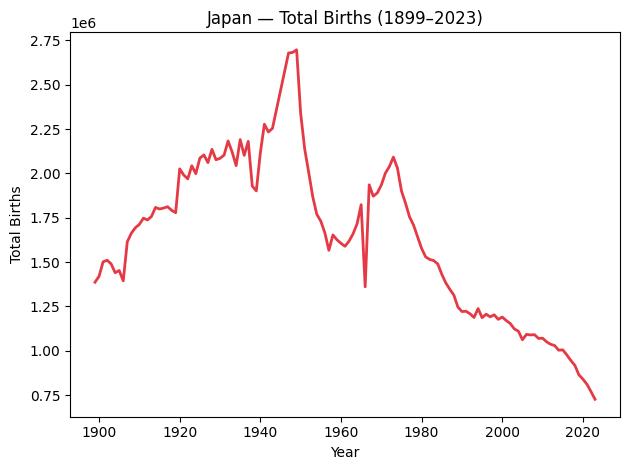

In [ ]:
# Total Births Over Time
fig, ax = plt.subplots()

ax.plot(df['year'], df['total_births'], color='#e63946', linewidth=2)

ax.set_title('Japan — Total Births (1899–2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Total Births')

plt.show()

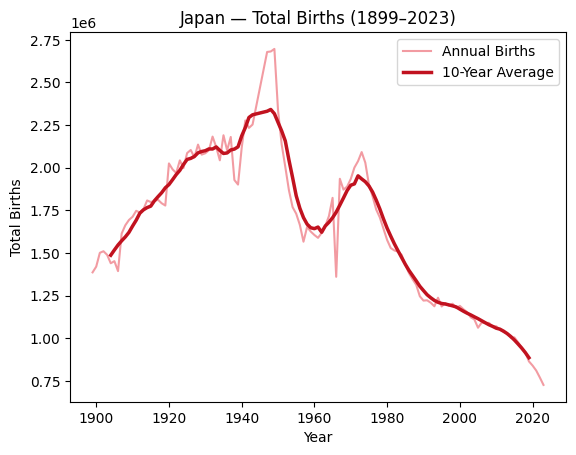

In [49]:
#Add 10-Year Rolling Average
rolling = df['total_births'].rolling(window=10, center=True).mean()

fig, ax = plt.subplots()

ax.plot(df['year'], df['total_births'],
        color='#e63946', linewidth=1.5, alpha=0.5, label='Annual Births')

ax.plot(df['year'], rolling,
        color='#c1121f', linewidth=2.5, label='10-Year Average')

ax.set_title('Japan — Total Births (1899–2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Total Births')
ax.legend()
plt.show()

In [28]:
df.to_csv("../data/backup_japan.csv")

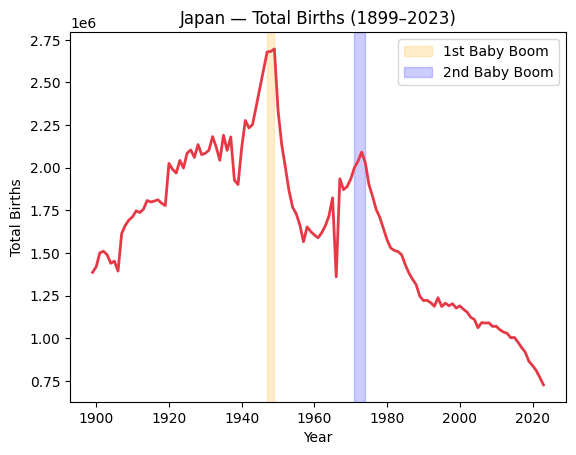

In [50]:
fig, ax = plt.subplots()

# line
ax.plot(df['year'], df['total_births'], color='#e63946', linewidth=2)

# shading baby boom periods using axvspan 
ax.axvspan(1947, 1949, alpha=0.2, color='orange', label='1st Baby Boom')
ax.axvspan(1971, 1974, alpha=0.2, color='blue',   label='2nd Baby Boom')

# labels
ax.set_title('Japan — Total Births (1899–2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Total Births')
ax.legend()
plt.show()

In between 1947 and 1940 first baby boom is been seen as after few year it starts to decase and gradully start it increase again in 1971 to 1974 2nd baby boom was seem this period and again from that the baby boom start to decrease due to demographic crisis 

# Male Vs Female Birth 

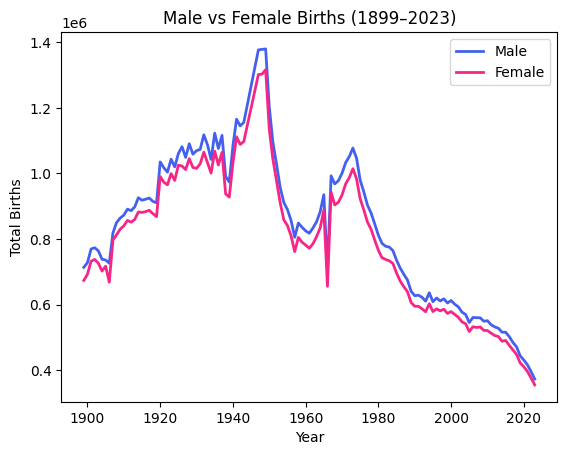

In [37]:
# Birth rate of Male and Female birth rate 
fig, ax = plt.subplots()

ax.plot(df['year'], df['male_births'],   color='#4361ee', linewidth=2, label='Male')
ax.plot(df['year'], df['female_births'], color='#f72585', linewidth=2, label='Female')

ax.set_title('Male vs Female Births (1899–2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Total Births')
ax.legend()

plt.show()

# Crude Birthrate rate vs Total Fertitlity rate


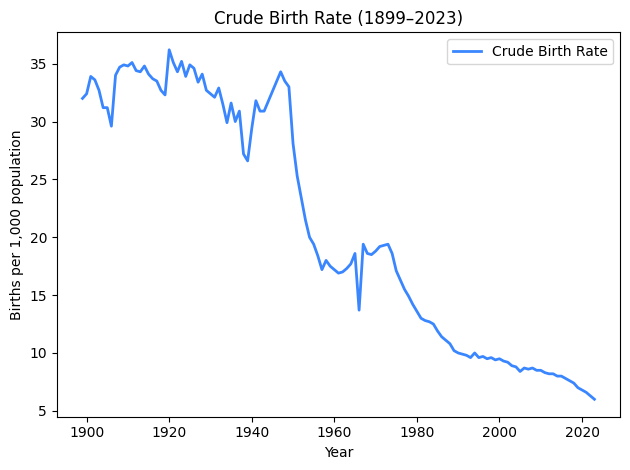

In [38]:
fig, ax = plt.subplots()

ax.plot(df['year'], df['crude_birth_rate'], color='#3a86ff', linewidth=2, label='Crude Birth Rate')

ax.set_title('Crude Birth Rate (1899–2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Births per 1,000 population')
ax.legend()

plt.tight_layout()
plt.show()

Between 1899 and 1920 (High & Stable), the CBR was approximately 32–36, which means that 32–36 babies were born annually for every 1,000 people. incredibly high by today's standards.
1920–1940 (Slow Drop)
gradually began to decline as Japan became more urbanized and modernized.
1940–1945 (Sharp Drop)
Families were split up and men were at war during World War II, which led to a sharp decline.
1945–1950 (Spike)
Post-war baby boom: As soldiers returned home, CBR rapidly increased again.
Continuous Decline, 1950–2023: Never recovered. decreased from about 28 to just 6 in 2023.

# Total Fertility Rate

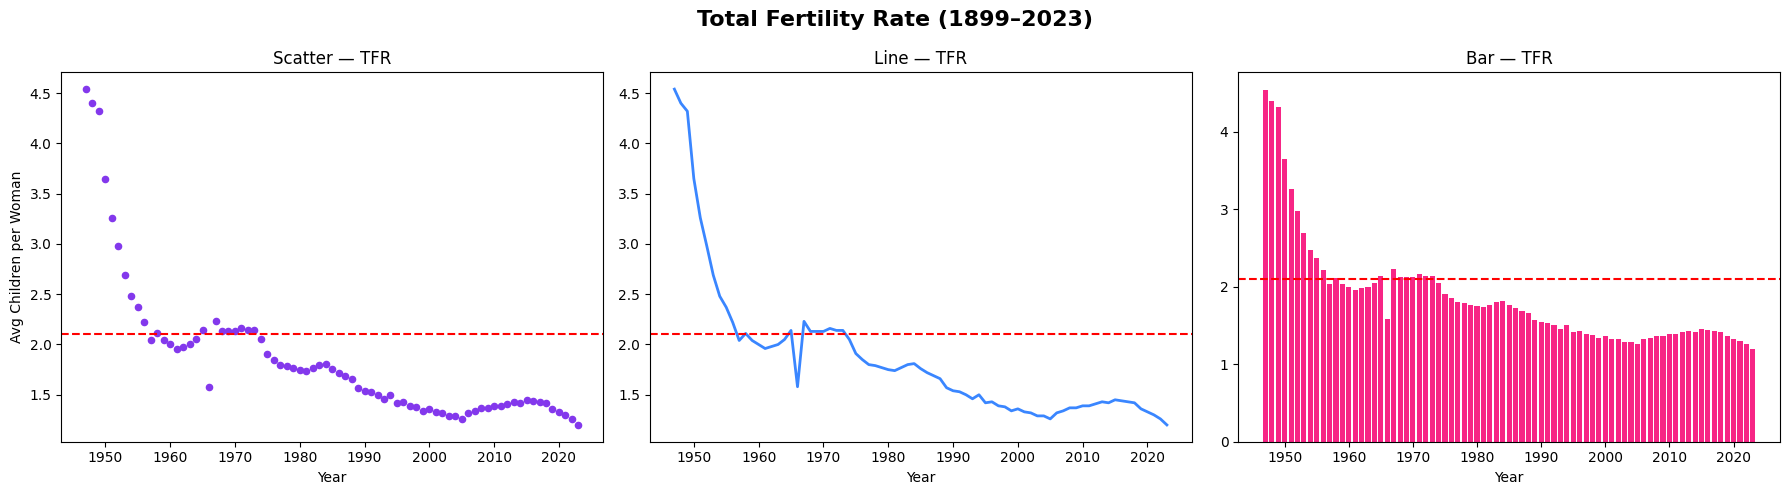

In [40]:
tfr = df.dropna(subset=['total_fertility_rate'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Scatter
axes[0].scatter(tfr['year'], tfr['total_fertility_rate'], color='#8338ec', s=20)
axes[0].axhline(y=2.1, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Scatter — TFR')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg Children per Woman')

# Chart 2 — Line
axes[1].plot(tfr['year'], tfr['total_fertility_rate'], color='#3a86ff', linewidth=2)
axes[1].axhline(y=2.1, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Line — TFR')
axes[1].set_xlabel('Year')

# Chart 3 — Bar
axes[2].bar(tfr['year'], tfr['total_fertility_rate'], color='#f72585', width=0.8)
axes[2].axhline(y=2.1, color='red', linewidth=1.5, linestyle='--')
axes[2].set_title('Bar — TFR')
axes[2].set_xlabel('Year')

plt.suptitle('Total Fertility Rate (1899–2023)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

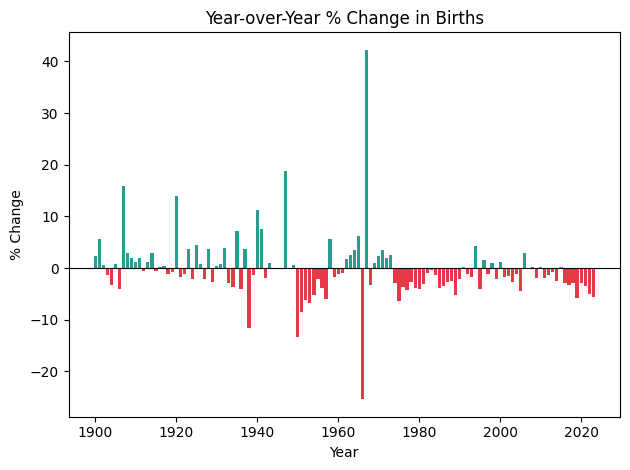

In [41]:
df['yoy_pct_change'] = df['total_births'].pct_change() * 100

fig, ax = plt.subplots()

colors = ['#e63946' if x < 0 else '#2a9d8f' for x in df['yoy_pct_change']]

ax.bar(df['year'], df['yoy_pct_change'], color=colors, width=0.8)
ax.axhline(y=0, color='black', linewidth=0.8)

ax.set_title('Year-over-Year % Change in Births')
ax.set_xlabel('Year')
ax.set_ylabel('% Change')

plt.tight_layout()
plt.show()

green bar above 0 shows births increased compared to previous year whereas red bar shows the births decreased compared to previous year

# Average Births by Era

In [45]:
def label_era(year):
     if year < 1945:   return 'Pre-War'
     elif year < 1960: return 'Post-War'
     elif year < 1975: return 'Baby Boom'
     elif year < 2000: return 'Decline'
     else:             return 'Crisis'

df['era'] = df['year'].apply(label_era)

print(df['era'].value_counts())

era
Pre-War      45
Decline      25
Crisis       24
Baby Boom    15
Post-War     13
Name: count, dtype: int64


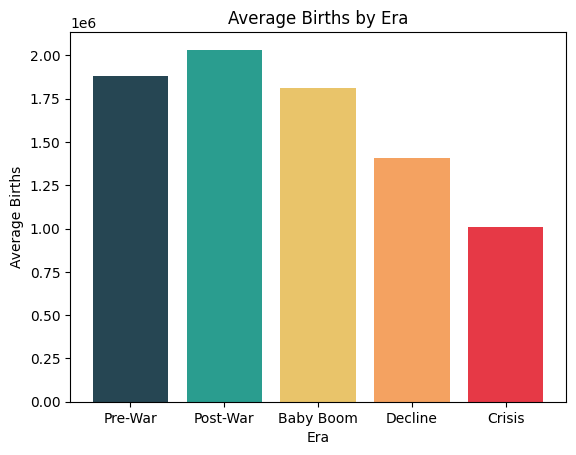

In [47]:
era_order = ['Pre-War', 'Post-War', 'Baby Boom', 'Decline', 'Crisis']

era_stats = df.groupby('era')['total_births'].mean().round(0)
era_stats = era_stats.loc[era_order]

fig, ax = plt.subplots()

ax.bar(era_stats.index, era_stats.values, color=['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e63946'])

ax.set_title('Average Births by Era')
ax.set_xlabel('Era')
ax.set_ylabel('Average Births')

plt.show()